In [ ]:
#Testing the code on fall and near fall data

import os
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [2]:
fall_folder = "data/nearFall"

In [ ]:
def load_fall_file(file_path):
    df = pd.read_csv(
        file_path,
        sep="\t",
        encoding="latin1",
        low_memory=False
    )

    sensor_cols = [
        'Ax(m/s²)', 'Ay(m/s²)', 'Az(m/s²)',
        'Rx(°/s)', 'Ry.(°/s)', 'Rz(°/s)'
    ]

    df = df[sensor_cols]

    df = df.apply(pd.to_numeric, errors='coerce')

    df = df.dropna()

    return df.values.astype(np.float32)


In [4]:
def load_fall_folder(folder):
    data_list = []
    for f in os.listdir(folder):
        if f.endswith(".csv"):
            file_path = os.path.join(folder, f)
            data = load_fall_file(file_path)
            data_list.append(data)
    if len(data_list) == 0:
        return None
    return np.vstack(data_list)

In [5]:
def create_windows(data, window=60, stride=15):
    windows = []
    for i in range(0, len(data) - window, stride):
        windows.append(data[i:i+window])
    return np.array(windows)

In [6]:
model = load_model("helmX_autoencoder.keras") 

In [7]:
mean = np.load("processed/mean.npy")
std = np.load("processed/std.npy")
threshold = np.load("processed/threshold.npy")

1750/1750 [==============================] - 81s 45ms/step


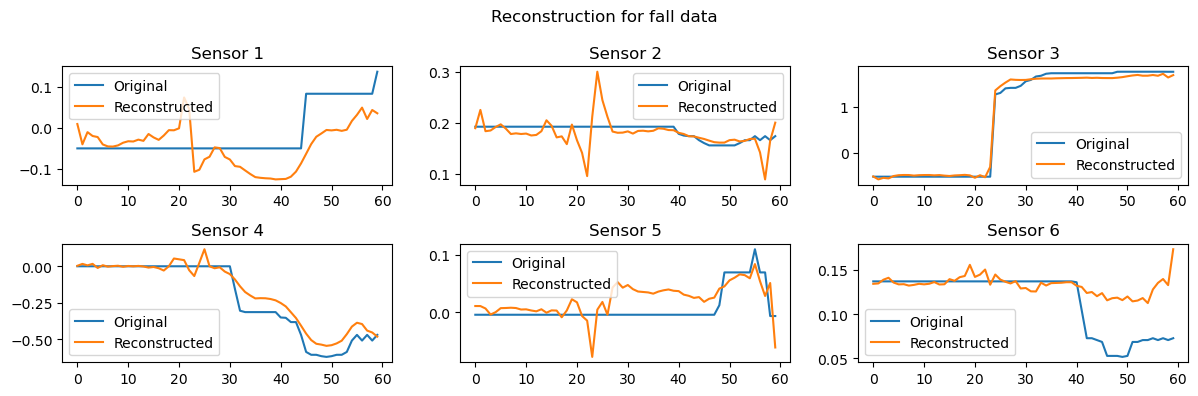

Average reconstruction error for fall data: 0.0761


In [ ]:
fall_data = load_fall_folder(fall_folder)

if fall_data is None:
    print(f"No CSV files found in {fall_folder}")
else:
    fall_windows = create_windows(fall_data)
    
    fall_windows = (fall_windows - mean) / std
    
    X_fall = np.transpose(fall_windows, (0,2,1))  # (N,6,60)
    X_fall = X_fall[..., np.newaxis]               # (N,6,60,1)
    
    reconstructed = model.predict(X_fall)

    sample_idx = 0
    plt.figure(figsize=(12,4))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.plot(X_fall[sample_idx, i, :, 0], label="Original")
        plt.plot(reconstructed[sample_idx, i, :, 0], label="Reconstructed")
        plt.title(f"Sensor {i+1}")
        plt.legend()
    plt.suptitle(f"Reconstruction for fall data")
    plt.tight_layout()
    plt.show()
    
    errors = np.mean((X_fall - reconstructed)**2, axis=(1,2,3))
    print(f"Average reconstruction error for fall data: {errors.mean():.4f}")

In [9]:
print("\nWindow-wise crash prediction:\n")

for i, err in enumerate(errors):
    is_crash = err > threshold
    status = "🚨 CRASH" if is_crash else "✅ NORMAL"
    
    print(
        f"Window {i:04d} | "
        f"Reconstruction Error = {err:.6f} | "
        f"Threshold = {threshold:.6f} | "
        f"{status}"
    )



Window-wise crash prediction:

Window 0000 | Reconstruction Error = 0.003110 | Threshold = 0.550146 | ✅ NORMAL
Window 0001 | Reconstruction Error = 0.004631 | Threshold = 0.550146 | ✅ NORMAL
Window 0002 | Reconstruction Error = 0.004601 | Threshold = 0.550146 | ✅ NORMAL
Window 0003 | Reconstruction Error = 0.004874 | Threshold = 0.550146 | ✅ NORMAL
Window 0004 | Reconstruction Error = 0.005763 | Threshold = 0.550146 | ✅ NORMAL
Window 0005 | Reconstruction Error = 0.005644 | Threshold = 0.550146 | ✅ NORMAL
Window 0006 | Reconstruction Error = 0.005390 | Threshold = 0.550146 | ✅ NORMAL
Window 0007 | Reconstruction Error = 0.004379 | Threshold = 0.550146 | ✅ NORMAL
Window 0008 | Reconstruction Error = 0.004153 | Threshold = 0.550146 | ✅ NORMAL
Window 0009 | Reconstruction Error = 0.004722 | Threshold = 0.550146 | ✅ NORMAL
Window 0010 | Reconstruction Error = 0.005072 | Threshold = 0.550146 | ✅ NORMAL
Window 0011 | Reconstruction Error = 0.005474 | Threshold = 0.550146 | ✅ NORMAL
Window 0

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [10]:
crash_windows = np.sum(errors > threshold)
total_windows = len(errors)

print("\nSummary:")
print(f"Total windows: {total_windows}")
print(f"Crash windows: {crash_windows}")
print(f"Crash ratio: {crash_windows/total_windows:.2%}")



Summary:
Total windows: 55974
Crash windows: 1109
Crash ratio: 1.98%


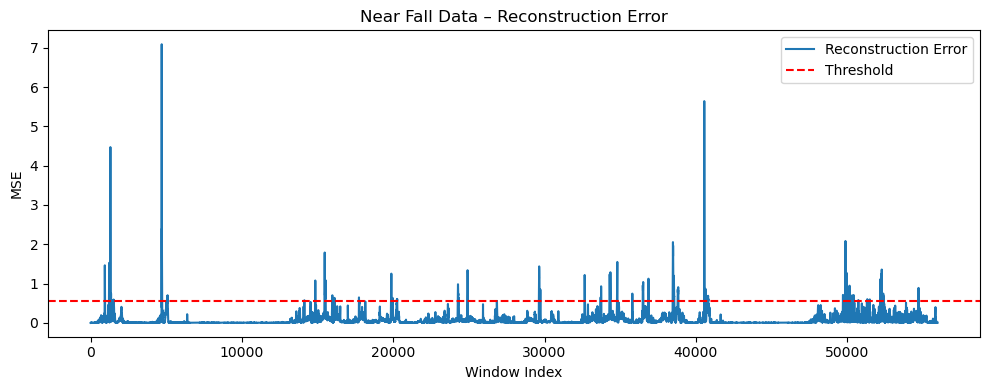

In [11]:
plt.figure(figsize=(10,4))
plt.plot(errors, label="Reconstruction Error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Window Index")
plt.ylabel("MSE")
plt.title("Near Fall Data – Reconstruction Error")
plt.legend()
plt.tight_layout()
plt.show()
